In [22]:
import pandas as pd
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prajwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\prajwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prajwal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prajwal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\prajwal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [23]:
import os

csv_path = r"C:\Users\prajwal\Desktop\Restaurant_Reviews.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("CSV loaded successfully")
    print(df.head())
else:
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

CSV loaded successfully
   Review_ID Customer_Name  Age  Gender Restaurant_Name   Location  \
0          1         Rahul   24    Male       Spice Hub  Bangalore   
1          2         Priya   28  Female      Pizza Town     Mysore   
2          3         Arjun   31    Male     Food Palace    Chennai   
3          4         Sneha   22  Female     Burger Spot  Bangalore   
4          5         Kiran   35    Male      Green Bowl  Hyderabad   

  Cuisine_Type Food_Item Order_Type  Visit_Date  ...  Payment_Method  \
0       Indian   Biryani    Dine-in  2026-01-05  ...             UPI   
1      Italian     Pizza   Delivery  2026-01-07  ...            Card   
2      Chinese   Noodles   Takeaway  2026-01-10  ...            Cash   
3    Fast Food    Burger   Delivery  2026-01-12  ...             UPI   
4      Healthy     Salad    Dine-in  2026-01-15  ...            Card   

  Discount_Used Delivery_Time_Min Delivery_Experience  Sentiment  \
0           Yes                 0                 NaN 

In [24]:
print(df.columns)

Index(['Review_ID', 'Customer_Name', 'Age', 'Gender', 'Restaurant_Name',
       'Location', 'Cuisine_Type', 'Food_Item', 'Order_Type', 'Visit_Date',
       'Rating', 'Review_Text', 'Food_Quality', 'Taste', 'Service_Rating',
       'Staff_Behavior', 'Cleanliness', 'Ambience', 'Waiting_Time_Min',
       'Price_Range', 'Payment_Method', 'Discount_Used', 'Delivery_Time_Min',
       'Delivery_Experience', 'Sentiment', 'Complaint_Type', 'Recommended',
       'Review_Length', 'Customer_Type', 'Feedback_Source'],
      dtype='object')


In [25]:
# Prepare the review text column for downstream processing
if "Review_Text" in df.columns:
    df["Review"] = df["Review_Text"].fillna("").astype(str)
elif {"Positive_Review", "Negative_Review"}.issubset(df.columns):
    df["Review"] = (
        df["Positive_Review"].fillna("").astype(str)
        + " "
        + df["Negative_Review"].fillna("").astype(str)
    )
else:
    raise KeyError("No suitable review text column found. Expected 'Review_Text' or 'Positive_Review'/'Negative_Review'.")

# Clean extra whitespace
df["Review"] = df["Review"].str.strip()

print(df[["Review"]].head())

                                         Review
0  Food was delicious and service was excellent
1               Pizza arrived late and was cold
2          Good taste but waiting time was high
3           Bad packaging and poor food quality
4           Fresh food and peaceful environment


In [26]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()   # No NLTK tokenizer needed

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [27]:
df["Clean_Review"] = df["Review"].apply(preprocess)

In [28]:
import sys
import subprocess

try:
    from textblob import TextBlob
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "textblob"])
    from textblob import TextBlob


def sentiment(review):
    score = TextBlob(review).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"


df["Sentiment"] = df["Clean_Review"].apply(sentiment)

In [29]:
issues = {
    "Room": ["room", "bed", "bathroom", "clean"],
    "Staff": ["staff", "manager", "reception", "service"],
    "Food": ["food", "breakfast", "dinner", "restaurant"],
    "Amenities": ["wifi", "pool", "gym", "parking", "spa"]
}

def identify_issue(review):
    found = []
    review = review.lower()

    for category, keywords in issues.items():
        if any(word in review for word in keywords):
            found.append(category)

    return ", ".join(found) if found else "Other"

df["Issue_Category"] = df["Review"].apply(identify_issue)

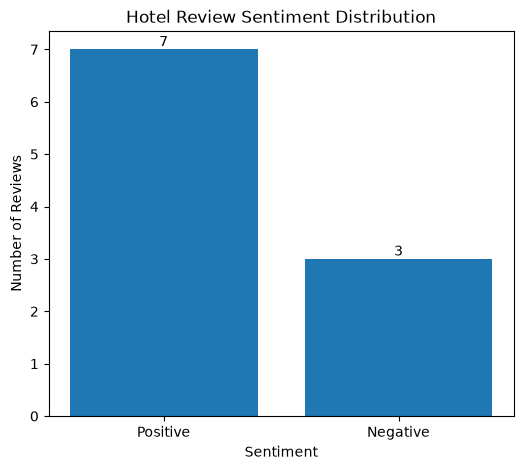

In [30]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df["Sentiment"].value_counts()

# Plot bar chart
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display values on bars
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

In [31]:
print(df[["Review", "Sentiment", "Issue_Category"]].head())

                                         Review Sentiment Issue_Category
0  Food was delicious and service was excellent  Positive    Staff, Food
1               Pizza arrived late and was cold  Negative          Other
2          Good taste but waiting time was high  Positive          Other
3           Bad packaging and poor food quality  Negative           Food
4           Fresh food and peaceful environment  Positive           Food


In [32]:
from collections import Counter

# Total reviews
total_reviews = len(df)

# Sentiment counts
sentiment_counts = df["Sentiment"].value_counts()

positive = sentiment_counts.get("Positive", 0)
neutral = sentiment_counts.get("Neutral", 0)
negative = sentiment_counts.get("Negative", 0)

# Percentages
positive_pct = (positive / total_reviews) * 100
neutral_pct = (neutral / total_reviews) * 100
negative_pct = (negative / total_reviews) * 100

# Count issue categories
issues = []
for item in df["Issue_Category"]:
    issues.extend(item.split(", "))

issue_counts = Counter(issues)

# Print Report
print("=" * 50)
print("      HOTEL CUSTOMER SATISFACTION REPORT")
print("=" * 50)

print(f"Total Reviews Analyzed : {total_reviews}")

print("\nSentiment Analysis")
print("-" * 50)
print(f"Positive Reviews : {positive} ({positive_pct:.2f}%)")
print(f"Neutral Reviews  : {neutral} ({neutral_pct:.2f}%)")
print(f"Negative Reviews : {negative} ({negative_pct:.2f}%)")

print("\nMost Mentioned Service Categories")
print("-" * 50)

for category, count in issue_counts.most_common():
    print(f"{category:<15} : {count}")

print("\nOverall Customer Satisfaction")
print("-" * 50)

if positive_pct >= 70:
    print("Excellent - Customers are highly satisfied.")
elif positive_pct >= 50:
    print("Good - Most customers are satisfied, but improvements are needed.")
else:
    print("Needs Improvement - Customer satisfaction is below expectations.")

print("=" * 50)

      HOTEL CUSTOMER SATISFACTION REPORT
Total Reviews Analyzed : 10

Sentiment Analysis
--------------------------------------------------
Positive Reviews : 7 (70.00%)
Neutral Reviews  : 0 (0.00%)
Negative Reviews : 3 (30.00%)

Most Mentioned Service Categories
--------------------------------------------------
Food            : 5
Other           : 5
Staff           : 1

Overall Customer Satisfaction
--------------------------------------------------
Excellent - Customers are highly satisfied.
